# **Sentiment Analysis - NLP Project**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

In [6]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/twitter_validation.csv", encoding="ISO-8859-1", header=None)
# Assign column names
df.columns = ['Id', 'Social_media', 'target', 'text']
df


Saving twitter_validation.csv to twitter_validation (4).csv


,Id,Social_media,target,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,â­ï¸ Toronto is the arts and culture capital...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [7]:
df.isna().sum()

Id              0
Social_media    0
target          0
text            0
dtype: int64

In [8]:
df.dtypes

Id               int64
Social_media    object
target          object
text            object
dtype: object

In [9]:
df['target'].value_counts()

target
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

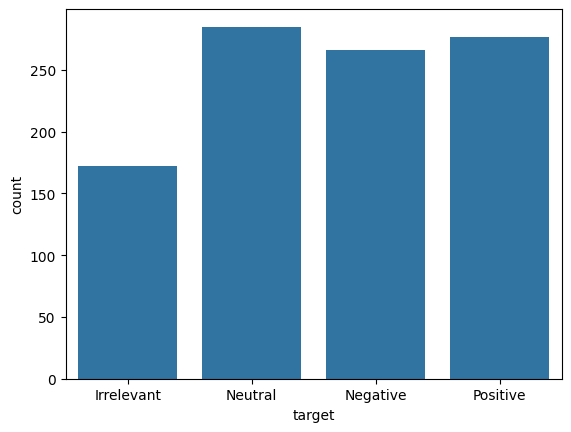

In [10]:
# Visualization
sns.countplot(x=df['target'], data=df)

In [11]:
df.drop(df.index[(df['target'] == 'Irrelevant')], axis=0, inplace = True)
df

,Id,Social_media,target,text
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
5,6273,FIFA,Negative,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...,...,...
993,314,Amazon,Negative,Please explain how this is possible! How can t...
994,9701,PlayStation5(PS5),Positive,Good on Sony. As much as I want to see the new...
997,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [12]:
df.reset_index(drop=True, inplace=True)
df

,Id,Social_media,target,text
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...,...,...
823,314,Amazon,Negative,Please explain how this is possible! How can t...
824,9701,PlayStation5(PS5),Positive,Good on Sony. As much as I want to see the new...
825,2652,Borderlands,Positive,Today sucked so itâs time to drink wine n pl...
826,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [13]:
df.drop(['Id', 'Social_media'], axis=1, inplace=True)
df

,target,text
0,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,Negative,@Microsoft Why do I pay for WORD when it funct...
2,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,Neutral,Now the President is slapping Americans in the...
4,Negative,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...
823,Negative,Please explain how this is possible! How can t...
824,Positive,Good on Sony. As much as I want to see the new...
825,Positive,Today sucked so itâs time to drink wine n pl...
826,Positive,Bought a fraction of Microsoft today. Small wins.


In [14]:
df['target']=df['target'].map({'Positive':1, 'Neutral':0, 'Negative': -1})
df

,target,text
0,0,BBC News - Amazon boss Jeff Bezos rejects clai...
1,-1,@Microsoft Why do I pay for WORD when it funct...
2,-1,"CSGO matchmaking is so full of closet hacking,..."
3,0,Now the President is slapping Americans in the...
4,-1,Hi @EAHelp Iâve had Madeleine McCann in my c...
...,...,...
823,-1,Please explain how this is possible! How can t...
824,1,Good on Sony. As much as I want to see the new...
825,1,Today sucked so itâs time to drink wine n pl...
826,1,Bought a fraction of Microsoft today. Small wins.


In [15]:
df.dtypes

target     int64
text      object
dtype: object

In [16]:
tweets = df.text
tweets

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking,...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp Iâve had Madeleine McCann in my c...
                             ...                        
823    Please explain how this is possible! How can t...
824    Good on Sony. As much as I want to see the new...
825    Today sucked so itâs time to drink wine n pl...
826    Bought a fraction of Microsoft today. Small wins.
827    Johnson & Johnson to stop selling talc baby po...
Name: text, Length: 828, dtype: object

In [17]:
# NLP (Natural Language Processing)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [18]:
# Tokenization
from nltk.tokenize import TweetTokenizer
tk = TweetTokenizer()
tweets=tweets.apply(lambda x:tk.tokenize(x)).apply(lambda x: " ".join(x))
tweets

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking ...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp Iâ   ve had Madeleine McCann in m...
                             ...                        
823    Please explain how this is possible ! How can ...
824    Good on Sony . As much as I want to see the ne...
825    Today sucked so itâ   s time to drink wine n...
826    Bought a fraction of Microsoft today . Small w...
827    Johnson & Johnson to stop selling talc baby po...
Name: text, Length: 828, dtype: object

In [19]:
# Remove Special Characters
tweets = tweets.str.replace('[^A-Za-z0-9]+',' ')  #$$$$
tweets

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking ...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp Iâ   ve had Madeleine McCann in m...
                             ...                        
823    Please explain how this is possible ! How can ...
824    Good on Sony . As much as I want to see the ne...
825    Today sucked so itâ   s time to drink wine n...
826    Bought a fraction of Microsoft today . Small w...
827    Johnson & Johnson to stop selling talc baby po...
Name: text, Length: 828, dtype: object

In [20]:
from nltk.tokenize import word_tokenize
tweets = tweets.apply(lambda x: ' '.join([w for w in word_tokenize(x) if len(w)>3]))
tweets

0      News Amazon boss Jeff Bezos rejects claims com...
1      Microsoft WORD when functions poorly SamsungUS...
2      CSGO matchmaking full closet hacking truly awf...
3      President slapping Americans face that really ...
4      EAHelp Madeleine McCann cellar past years litt...
                             ...                        
823    Please explain this possible they companies ov...
824    Good Sony much want what going right much more...
825    Today sucked time drink wine play borderlands ...
826           Bought fraction Microsoft today Small wins
827    Johnson Johnson stop selling talc baby powder ...
Name: text, Length: 828, dtype: object

In [21]:
# Stemming
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')
tweets = tweets.apply(lambda x: [stemmer.stem(i.lower()) for i in tk.tokenize(x)]).apply(lambda x: ' '.join(x))


In [23]:
# Stopwords Removing
from nltk.corpus import stopwords
sw = stopwords.words('english')
tweets = tweets.apply(lambda x: [i for i in tk.tokenize(x) if i not in sw]).apply(lambda x:' '.join(x))
tweets


0      news amazon boss jeff bezo reject claim compan...
1      microsoft word function poor samsungus chromebook
2           csgo matchmak full closet hack truli aw game
3      presid slap american face realli commit unlaw ...
4      eahelp madelein mccann cellar past year littl ...
                             ...                        
823    pleas explain possibl compani overcharg scam a...
824             good soni much want go right much import
825    today suck time drink wine play borderland com...
826            bought fraction microsoft today small win
827    johnson johnson stop sell talc babi powder can...
Name: text, Length: 828, dtype: object

In [30]:
# Vectorization - TF - IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer()
train_data = vec.fit_transform(tweets)
print(train_data.shape)

(828, 3663)


In [32]:
y = df['target'].values
y


array([ 0, -1, -1,  0, -1,  1,  1,  1, -1,  1,  1, -1,  0, -1,  1,  1, -1,
        1, -1, -1,  0, -1,  0,  0, -1, -1,  1,  1, -1,  1, -1,  0,  0,  1,
        0,  1,  0,  0,  0,  1,  0, -1, -1, -1,  0,  1, -1, -1,  1,  1,  1,
        1,  1, -1, -1,  1,  1, -1,  0, -1,  0, -1,  1, -1, -1,  1,  1,  1,
        0,  0,  0,  1,  1,  0,  1,  0, -1, -1,  0,  0, -1,  1, -1, -1, -1,
        0,  1,  0, -1,  1,  1,  0,  1,  0,  1, -1,  0,  0,  0, -1,  0, -1,
        0,  0,  1,  1,  0, -1, -1,  1, -1,  0, -1,  1,  0, -1,  0,  1,  0,
        1,  1,  0,  0,  0,  0,  1,  0,  1,  1, -1,  0,  0,  0,  0, -1,  0,
        1, -1,  0, -1,  0, -1, -1, -1,  1,  1,  1,  0,  0,  1,  0,  0,  0,
        1,  0, -1, -1,  0,  1,  1,  0,  1,  1,  0,  0, -1, -1, -1, -1,  1,
        0,  0,  1,  1,  1,  1, -1,  1,  1,  0, -1, -1, -1,  1,  1, -1, -1,
        1,  1, -1,  1,  1, -1,  1,  0, -1,  0,  0,  1, -1,  1,  1,  0,  1,
       -1, -1,  1,  1,  1,  1,  0,  0,  1, -1,  0,  1,  0, -1,  0,  0, -1,
        1,  1, -1,  0,  1

In [33]:
x = train_data
x

<828x3663 sparse matrix of type '<class 'numpy.float64'>'
	with 9730 stored elements in Compressed Sparse Row format>

In [35]:
from sklearn.model_selection import train_test_split

# Assuming x and y are defined
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

x_train


<662x3663 sparse matrix of type '<class 'numpy.float64'>'
	with 7819 stored elements in Compressed Sparse Row format>

In [36]:
# Model Creation" KNN, Naive Bayes, SVC and DecisionTree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
knn = KNeighborsClassifier(n_neighbors=7)
model = BernoulliNB()
model1 = SVC()
model2 = DecisionTreeClassifier()
lst = [knn, model, model1, model2]

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
for i in lst:
  print(i)
  i.fit(x_train, y_train)
  y_pred = i.predict(x_test)
  print(accuracy_score(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))

KNeighborsClassifier(n_neighbors=7)
0.40963855421686746
[[21  0 34]
 [19  1 26]
 [19  0 46]]
BernoulliNB()
0.5662650602409639
[[34  4 17]
 [12 14 20]
 [14  5 46]]
SVC()
0.5301204819277109
[[23 26  6]
 [ 5 35  6]
 [ 6 29 30]]
DecisionTreeClassifier()
0.37349397590361444
[[30 14 11]
 [13 20 13]
 [34 19 12]]
